Задание 1. Реализовать самостоятельно функцию 2d depth -> 3d point cloud. Как тест решения - функцию обратного преобразования (3d -> 2d). В результате обратного преобразования вы должны получить карту глубины, которая отличается от исходной не более, чем 1e−3

assert np.allclose(depth_restored[mask], depth_original[mask], atol=1e-4)

На вход: карта глубины (1, h, w) где в каждом пикселе depth-карты хранится значение глубины Z в системе координат камеры, интринсики (3, 3) На выход: массив (N, 3), где в последней мерности координаты x, y, z

Иными словами - нужно перевести u, v - координаты пикселей в карте глубины и z - значение пикселя, расстояние до объекта в метрах или милиметрах в облако точек, где каждая точка имеет координату X, Y, Z. 

Если материалов семинара не хватает - можно заглянуть сюда https://facebookresearch.github.io/projectaria_tools/docs/tech_insights/camera_intrinsic_models

Что сдавать: код, примеры с визуализацией и тесты для обратного преобразования.

стоимость - 2 балла

In [1]:

import os
from IPython.display import clear_output


notebook_dir = "/home/balabaevvl/courses/sdc/sdc_course/seminar05-camera-only/src"

os.chdir(notebook_dir)

GPUs = [
    "GPU-e83bd31b-fcb9-b8de-f617-2d717619413b",
    "GPU-5a9b7750-9f85-49a5-3aae-fe07b1b7661d",
    "GPU-fe2d8dfd-06f2-a5c4-a7fd-4a5f23947005",
    "GPU-0c320096-21ee-4060-8731-826ca2febfab",
    "GPU-baef952c-6609-aace-3b78-e4e07788d5de",
    "GPU-3979d65b-c238-4e9c-0c1c-1aa3f05c56a1",
    "GPU-6c76a2c5-5375-aa06-11d4-0fddfac30e91",
]
os.environ["CUDA_VISIBLE_DEVICES"] = f"{GPUs[2]}"


In [2]:
!pip install pyquaternion
!pip install nuscenes-devkit efficientnet_pytorch==0.7.0

import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import requests
from urllib.parse import urlencode

# Add src to path (works both locally and on Colab)
_notebook_dir = os.path.abspath('.')
_src_dir = os.path.join(os.path.dirname(_notebook_dir), 'src')
if os.path.isdir(_src_dir):
    sys.path.insert(0, _src_dir)
else:
    # On Colab, source files are typically downloaded to CWD
    sys.path.insert(0, _notebook_dir)

np.set_printoptions(precision=3)
%matplotlib inline


def download_from_yadisk(short_url: str, filename: str, target_dir: str):
    base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
    final_url = base_url + urlencode(dict(public_key=short_url))
    response = requests.get(final_url)
    download_url = response.json()['href']
    download_response = requests.get(download_url)
    target_file = os.path.join(target_dir, filename)
    with open(target_file, 'wb') as f:
        f.write(download_response.content)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# for task 1
download_from_yadisk("https://disk.yandex.ru/d/l0_zM_F39leAPQ", 
                               "depth_data.zip",
                               target_dir='.')
!unzip -o depth_data.zip

Archive:  depth_data.zip
   creating: depth_data/
  inflating: depth_data/depth2.npy   
  inflating: depth_data/depth1.npy   
  inflating: depth_data/depth3.npy   


In [4]:
depth1 = np.load("depth_data/depth1.npy")
depth2 = np.load("depth_data/depth2.npy")
depth3 = np.load("depth_data/depth3.npy")

# Предполагается стандартная pinhole camera model без дисторсии
intrinsics = [366.778564453125, 0.0, 318.3612365722656, 0.0, 0.0, 366.778564453125, 176.17840576171875, 0.0, 0.0, 0.0, 1.0, 0.0]

In [5]:
# ===================== Задание 1 =====================
# Парсим интринсики из плоского списка (3x4 projection matrix -> 3x3 K)
K = np.array(intrinsics).reshape(3, 4)[:, :3]
print("Intrinsics matrix K:")
print(K)

fx, fy = K[0, 0], K[1, 1]
cx, cy = K[0, 2], K[1, 2]
print(f"\nfx={fx}, fy={fy}, cx={cx}, cy={cy}")

print(f"\nDepth shapes: depth1={depth1.shape}, depth2={depth2.shape}, depth3={depth3.shape}")


def depth_to_pointcloud(depth_map, K):
    """
    Convert 2D depth map to 3D point cloud using pinhole camera model.
    
    Args:
        depth_map: np.array of shape (H, W) or (1, H, W) - depth values (Z in camera frame)
        K: np.array of shape (3, 3) - camera intrinsics matrix
    
    Returns:
        points: np.array of shape (N, 3) - 3D point cloud (X, Y, Z)
    """
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    
    # Handle both (H, W) and (1, H, W) inputs
    if depth_map.ndim == 3:
        z = depth_map[0]
    else:
        z = depth_map
    h, w = z.shape
    
    # Create pixel coordinate grids
    u, v = np.meshgrid(np.arange(w), np.arange(h))  # (H, W) each
    
    # Mask valid (non-zero) depth
    mask = z > 0
    
    z_valid = z[mask].astype(np.float64)
    u_valid = u[mask].astype(np.float64)
    v_valid = v[mask].astype(np.float64)
    
    # Unproject: (u, v, z) -> (X, Y, Z)
    x = (u_valid - cx) * z_valid / fx
    y = (v_valid - cy) * z_valid / fy
    
    points = np.stack([x, y, z_valid], axis=-1)  # (N, 3)
    return points


def pointcloud_to_depth(points, K, h, w):
    """
    Project 3D point cloud back to 2D depth map using pinhole camera model.
    
    Args:
        points: np.array of shape (N, 3) - 3D point cloud (X, Y, Z)
        K: np.array of shape (3, 3) - camera intrinsics matrix
        h, w: int - height and width of the output depth map
    
    Returns:
        depth_map: np.array of shape (H, W) - restored depth map
    """
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    
    X, Y, Z = points[:, 0], points[:, 1], points[:, 2]
    
    # Project: (X, Y, Z) -> (u, v)
    # Use rounding to avoid truncation errors (e.g. 4.9999 -> 4 instead of 5)
    u = np.round(fx * X / Z + cx).astype(np.int32)
    v = np.round(fy * Y / Z + cy).astype(np.int32)
    
    # Filter valid projections
    valid = (u >= 0) & (u < w) & (v >= 0) & (v < h) & (Z > 0)
    
    depth_restored = np.zeros((h, w), dtype=np.float64)
    depth_restored[v[valid], u[valid]] = Z[valid]
    
    return depth_restored


# ===================== Тестирование на всех depth картах =====================
for i, depth_original in enumerate([depth1, depth2, depth3], 1):
    # Normalize to 2D for consistent handling
    d = depth_original[0] if depth_original.ndim == 3 else depth_original
    
    print(f"\n--- Depth map {i} ---")
    print(f"  Shape: {depth_original.shape}, dtype: {depth_original.dtype}")
    print(f"  Range: [{d.min():.3f}, {d.max():.3f}]")
    
    # Forward: depth -> point cloud
    pc = depth_to_pointcloud(depth_original, K)
    print(f"  Point cloud: {pc.shape[0]} points")
    
    # Backward: point cloud -> depth
    h, w = d.shape
    depth_restored = pointcloud_to_depth(pc, K, h, w)
    
    # Test: compare restored depth with original
    mask = d > 0
    max_diff = np.max(np.abs(depth_restored[mask] - d[mask]))
    print(f"  Max difference: {max_diff:.2e}")
    
    assert np.allclose(depth_restored[mask], d[mask], atol=1e-4), \
        f"Depth map {i}: restoration error too large! max_diff={max_diff}"
    print(f"  PASSED: assert np.allclose(..., atol=1e-4)")

print("\nAll tests passed!")

Intrinsics matrix K:
[[366.779   0.    318.361]
 [  0.    366.779 176.178]
 [  0.      0.      1.   ]]

fx=366.778564453125, fy=366.778564453125, cx=318.3612365722656, cy=176.17840576171875

Depth shapes: depth1=(360, 640), depth2=(360, 640), depth3=(360, 640)

--- Depth map 1 ---
  Shape: (360, 640), dtype: float32
  Range: [0.000, 10.000]
  Point cloud: 202892 points
  Max difference: 0.00e+00
  PASSED: assert np.allclose(..., atol=1e-4)

--- Depth map 2 ---
  Shape: (360, 640), dtype: float32
  Range: [0.000, 10.000]
  Point cloud: 147305 points
  Max difference: 0.00e+00
  PASSED: assert np.allclose(..., atol=1e-4)

--- Depth map 3 ---
  Shape: (360, 640), dtype: float32
  Range: [0.000, 10.000]
  Point cloud: 171993 points
  Max difference: 0.00e+00
  PASSED: assert np.allclose(..., atol=1e-4)

All tests passed!


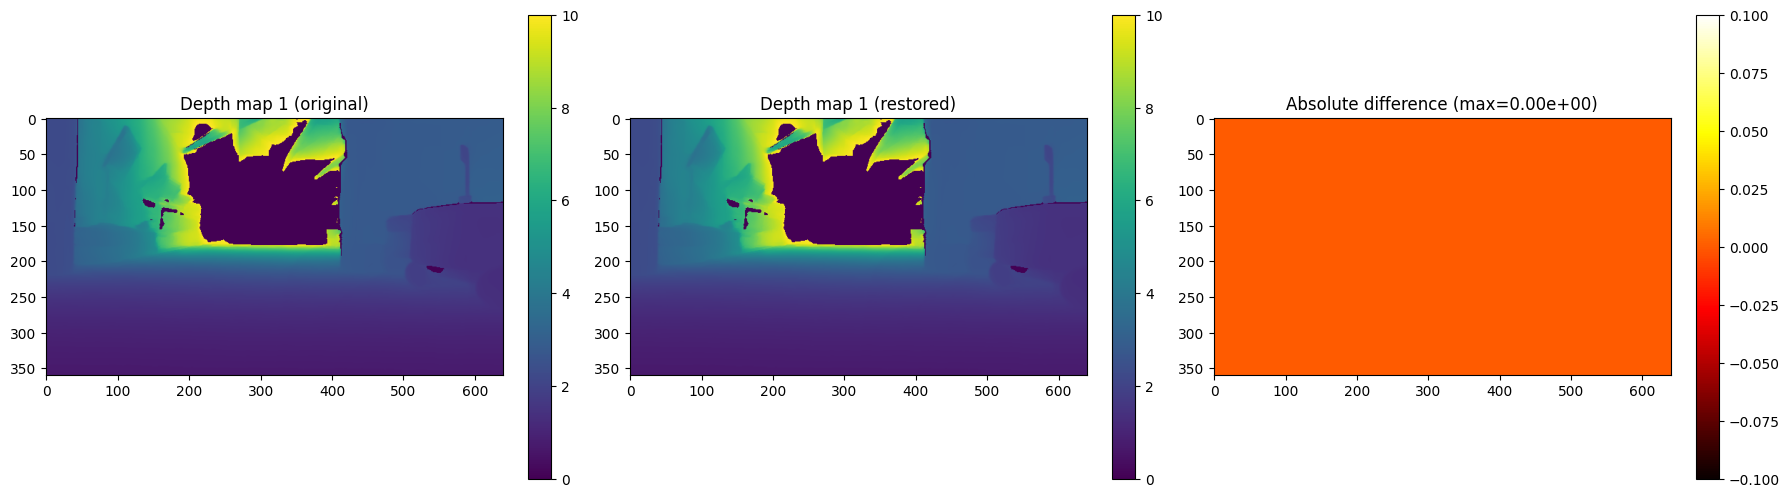

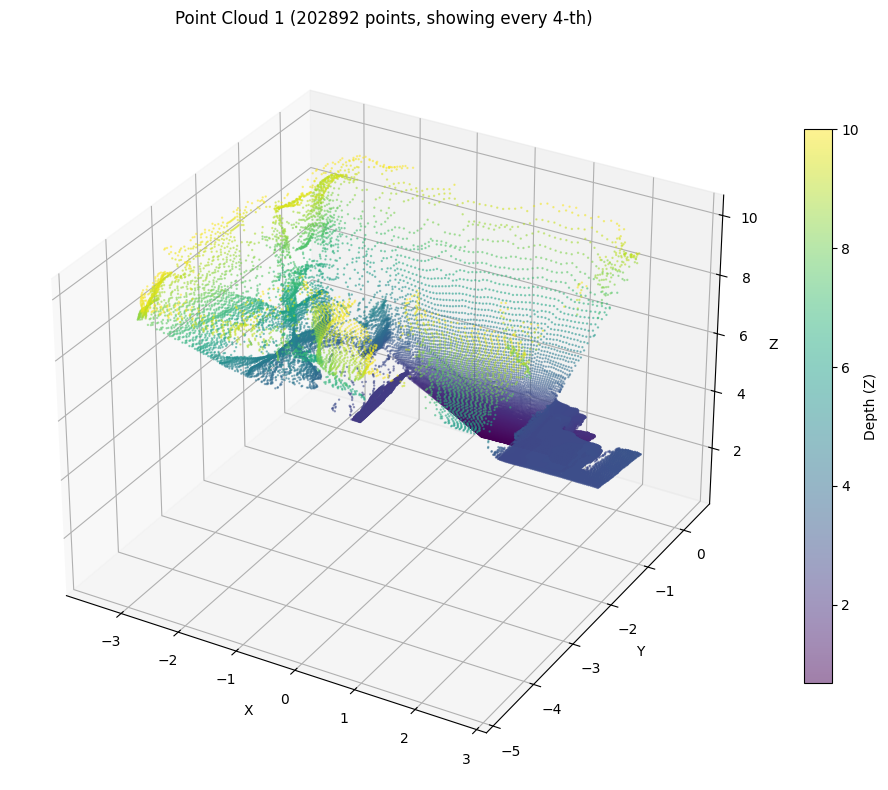

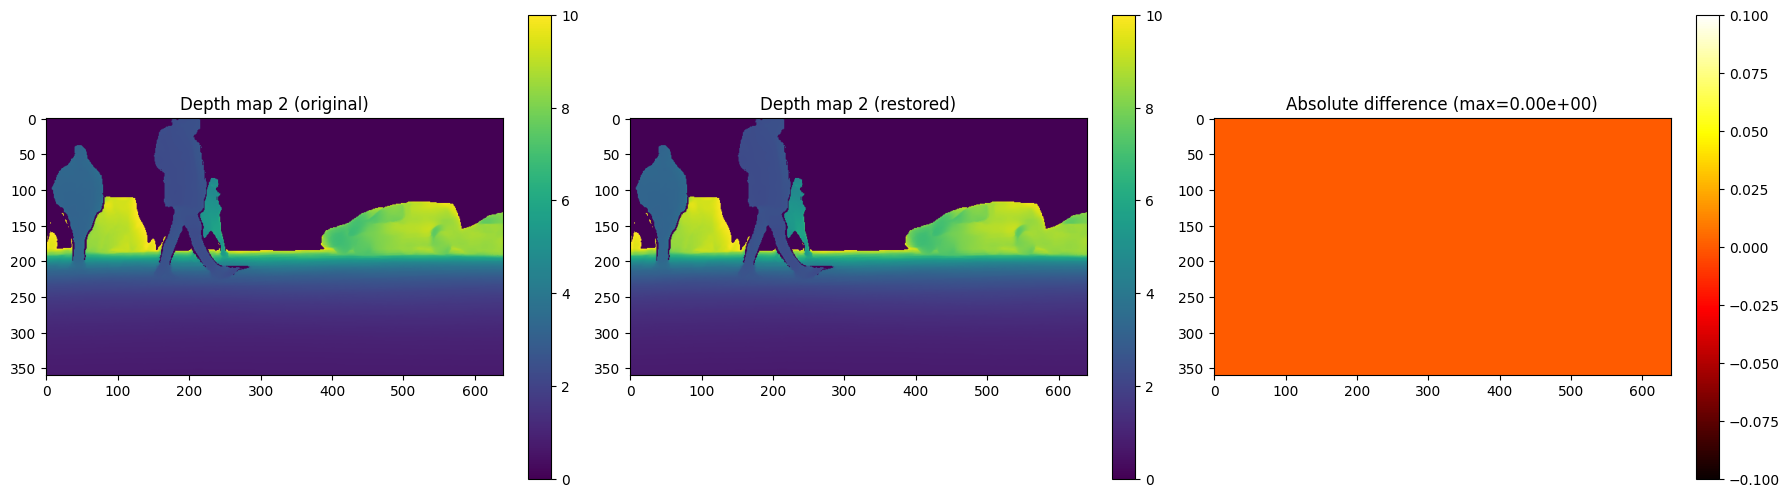

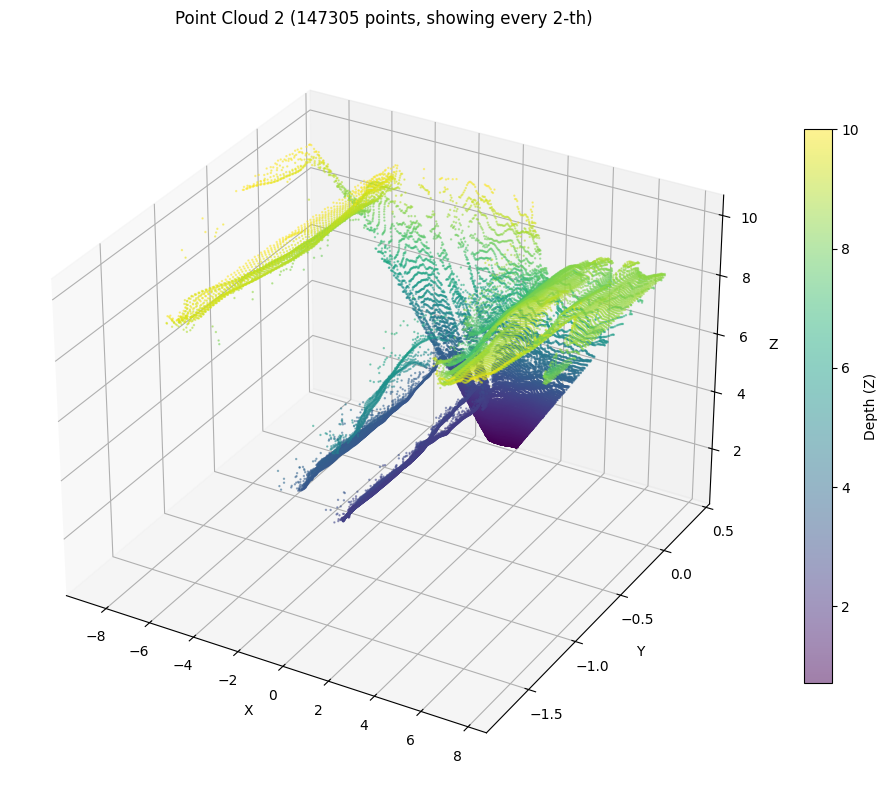

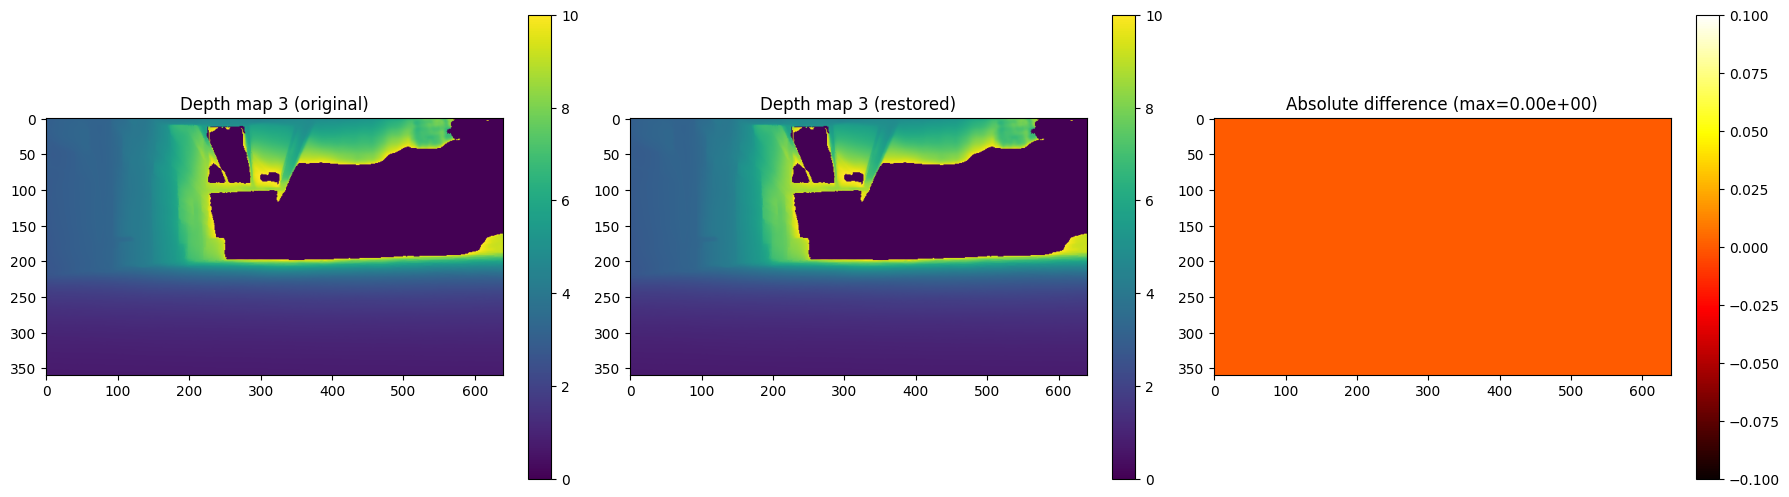

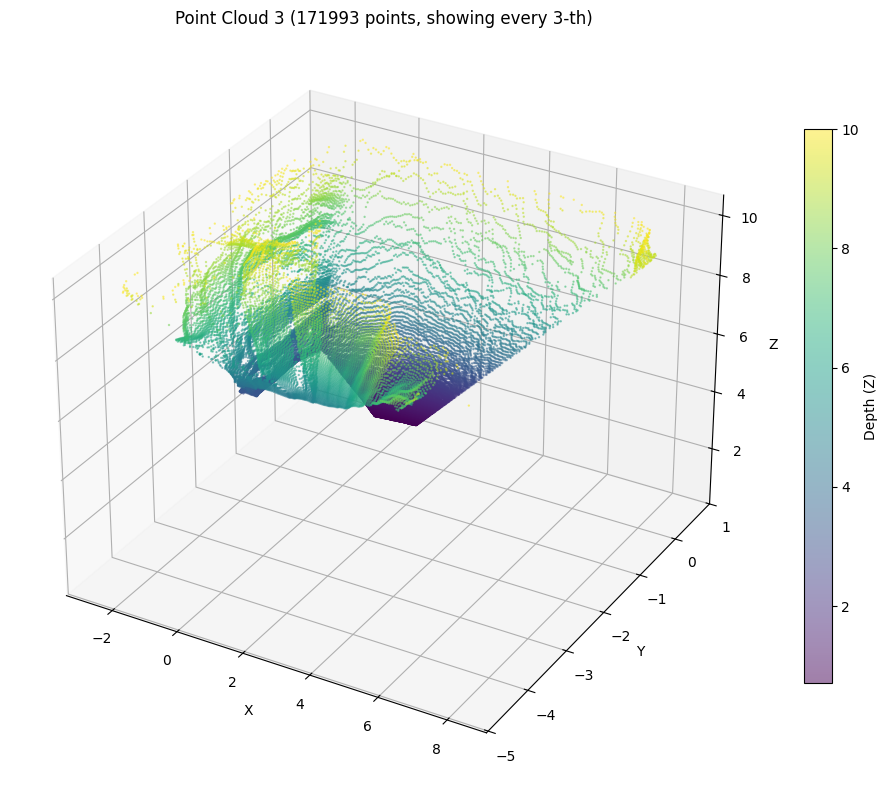

In [6]:
# ===================== Визуализация задания 1 =====================
from mpl_toolkits.mplot3d import Axes3D

for i, depth_original in enumerate([depth1, depth2, depth3], 1):
    d = depth_original[0] if depth_original.ndim == 3 else depth_original
    
    pc = depth_to_pointcloud(depth_original, K)
    h, w = d.shape
    depth_restored = pointcloud_to_depth(pc, K, h, w)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Original depth map
    im0 = axes[0].imshow(d, cmap='viridis')
    axes[0].set_title(f'Depth map {i} (original)')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # Restored depth map
    im1 = axes[1].imshow(depth_restored, cmap='viridis')
    axes[1].set_title(f'Depth map {i} (restored)')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Difference
    diff = np.abs(depth_restored - d)
    im2 = axes[2].imshow(diff, cmap='hot')
    axes[2].set_title(f'Absolute difference (max={diff.max():.2e})')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    plt.tight_layout()
    plt.show()
    
    # 3D point cloud visualization (subsample for speed)
    step = max(1, len(pc) // 50000)
    pc_sub = pc[::step]
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(pc_sub[:, 0], pc_sub[:, 1], pc_sub[:, 2], 
                         c=pc_sub[:, 2], cmap='viridis', s=0.5, alpha=0.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Point Cloud {i} ({len(pc)} points, showing every {step}-th)')
    plt.colorbar(scatter, ax=ax, fraction=0.03, label='Depth (Z)')
    plt.tight_layout()
    plt.show()

In [7]:
!pip install pyquaternion
!pip install nuscenes-devkit efficientnet_pytorch==0.7.0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Возвращаемся к модели LSS.

Задание 2 - запустить и прогнать инференс сети LSS (это уже делалось на семинаре). Написать визуализацию проекции BEV-сегментации на изображения, вывести визуализацию для 3-5 примеров из инференса, и для ground true, и для prediction. 

В качестве визуализации хотелось бы видеть похожее на визуализацию из NuScense (прокрас объектов точками):
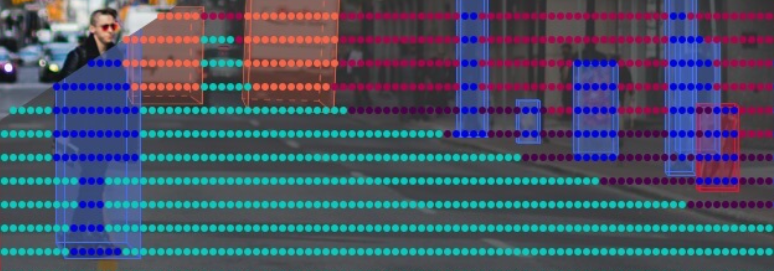

В нашем случае bev-сегментация бинарная (препятствие / не препятствие), так что точки будут в одном цвете.
Визуализацию делаем для всех камер для одного примера. Достаточно 7-10 рандомных примеров из датасета.

Что сдавать: ноутбук с кодом и с визуализациями.

В ячейках ниже - повтор краткого содержания и концепции модели и основной код для прогона инференса.

Стоимость - 3 балла.

TLDR: Что такое Lift-Splat-Shot модель?

Это одна из базовых camera-only моделей, может быть включена в большую perception модель (например, BEV-Fusion), может быть использована самостоятельно.

Состоит из трёх этапов:

Lift (Подъём): На этом этапе изображения, полученные с камер, проецируются в трёхмерное пространство. Это делается с использованием информации о интринсиках камеры и глубине (или псевдоглубине), чтобы определить, где каждый пиксель изображения находится в трёхмерном пространстве.

Splat ("Разбрызгивание"): После проекции данных в 3D-пространство, они распределяются по трёхмерной сетке (Frutsum). Это позволяет создать плотное представление сцены, где каждый элемент сетки содержит информацию о своём окружении.

Shoot: На последнем этапе модель использует полученное трёхмерное представление для выполнения различных задач, таких как обнаружение объектов, оценка расстояний или прогнозирование движения. Это позволяет системе принимать решения на основе более полной информации о сцене.

In [ ]:
# код для скачивания данных

!mkdir -p /data/sets/nuscenes  # Make the directory to store the nuScenes dataset in.

!wget https://www.nuscenes.org/data/v1.0-mini.tgz  # Download the nuScenes mini split.

!tar -xf v1.0-mini.tgz -C /data/sets/nuscenes  # Uncompress the nuScenes mini split.

In [9]:
# размер изображения

H=900
W=1600

# размеры на вход и на выход
resize_lim=(0.193, 0.225)
final_dim=(128, 352)
bot_pct_lim=(0.0, 0.22)
rot_lim=(-5.4, 5.4)
rand_flip=True

# параметры грида

xbound=[-50.0, 50.0, 0.5]
ybound=[-50.0, 50.0, 0.5]
zbound=[-10.0, 10.0, 20.0]
dbound=[4.0, 45.0, 1.0]

In [10]:
grid_conf = {
        'xbound': xbound,
        'ybound': ybound,
        'zbound': zbound,
        'dbound': dbound,
    }
    
    
data_aug_conf = {
                    'resize_lim': resize_lim,
                    'final_dim': final_dim,
                    'rot_lim': rot_lim,
                    'H': H, 'W': W,
                    'rand_flip': rand_flip,
                    'bot_pct_lim': bot_pct_lim,
                    'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
                             'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'],
                    'Ncams': 5,
                }

In [11]:
# download pretrained model
download_from_yadisk("https://disk.yandex.ru/d/m5xDFY8JnWsUhg", 
                               "model_pretrained.pt",
                               target_dir='.')

In [12]:
from data import compile_data
from tools import (ego_to_cam, get_only_in_img_mask, denormalize_img,
                    SimpleLoss, get_val_info, add_ego, gen_dx_bx,
                    get_nusc_maps, plot_nusc_map, visualize_binmgs)
from models import compile_model

In [ ]:
# тест данных Nuscense
trainloader, valloader = compile_data("mini", "/data/sets/nuscenes", data_aug_conf=data_aug_conf,
                                          grid_conf=grid_conf, bsz=4, nworkers=1,
                                          parser_name='segmentationdata')

In [ ]:
device = torch.device(f'cuda:0') # рекомендуется пользоваться машиной с GPU

model = compile_model(grid_conf, data_aug_conf, outC=1)
model.load_state_dict(torch.load('model_pretrained.pt'))
model.to(device)

loss_fn = SimpleLoss(1.0).cuda(0)

model.eval()

In [ ]:
# запуск одной итерации LSS на val

with torch.no_grad():
    for batch in valloader:
        allimgs, rots, trans, intrins, post_rots, post_trans, binimgs = batch
        preds = model(allimgs.to(device), rots.to(device),
                          trans.to(device), intrins.to(device), post_rots.to(device),
                          post_trans.to(device))
        binimgs = binimgs.to(device)
        break

In [ ]:
# ===================== Задание 2 =====================
# Проекция BEV-сегментации на изображения камер
from tools import gen_dx_bx, denormalize_img, ego_to_cam, get_only_in_img_mask
from PIL import Image

dx, bx, nx = gen_dx_bx(grid_conf['xbound'], grid_conf['ybound'], grid_conf['zbound'])

cams = ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
        'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT']


def bev_to_ego_points(bev_map, dx, bx, z_values=None):
    """
    Convert BEV binary map to 3D ego-frame points.
    bev_map: (H_bev, W_bev) binary map
    Returns: (3, N) tensor of ego-frame points
    """
    if z_values is None:
        z_values = [0.0]  # ground plane
    
    # Find occupied pixels in BEV
    occupied = (bev_map > 0).nonzero(as_tuple=True)
    if len(occupied[0]) == 0:
        return torch.zeros(3, 0)
    
    yi, xi = occupied  # BEV grid indices
    
    all_points = []
    for z in z_values:
        # Convert BEV grid indices to ego coordinates
        # BEV grid: index -> real coordinate
        x_ego = xi.float() * dx[0] + bx[0] - dx[0] / 2
        y_ego = yi.float() * dx[1] + bx[1] - dx[1] / 2
        z_ego = torch.full_like(x_ego, z)
        
        pts = torch.stack([x_ego, y_ego, z_ego], dim=0)  # (3, N)
        all_points.append(pts)
    
    return torch.cat(all_points, dim=1)


def visualize_bev_on_cameras(imgs, rots, trans, intrins, post_rots, post_trans, 
                              bev_map, sample_idx, dx, bx, title_prefix=""):
    """
    Project BEV segmentation onto all 6 camera images.
    """
    # Generate 3D points from BEV at multiple heights for better visibility
    z_values = [-1.0, -0.5, 0.0, 0.5, 1.0]
    ego_pts = bev_to_ego_points(bev_map, dx, bx, z_values=z_values)
    
    if ego_pts.shape[1] == 0:
        print("No occupied BEV cells found")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    
    for cam_idx in range(6):
        row, col = cam_idx // 3, cam_idx % 3
        ax = axes[row, col]
        
        # Denormalize and show image
        img = denormalize_img(imgs[sample_idx, cam_idx])
        
        # Flip back images for display consistency
        if cam_idx > 2:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        
        ax.imshow(img)
        
        # Project ego points to this camera
        cam_pts = ego_to_cam(ego_pts, 
                             rots[sample_idx, cam_idx], 
                             trans[sample_idx, cam_idx], 
                             intrins[sample_idx, cam_idx])
        
        # Apply post-transform (augmentation)
        cam_pts_2d = post_rots[sample_idx, cam_idx].matmul(cam_pts) + \
                     post_trans[sample_idx, cam_idx].unsqueeze(1)
        
        # Get valid points (in image and in front of camera)
        fH, fW = final_dim
        mask = get_only_in_img_mask(cam_pts_2d, fH, fW)
        
        if cam_idx > 2:
            # Flip x coordinates for back cameras
            plot_x = fW - 1 - cam_pts_2d[0, mask].cpu().numpy()
        else:
            plot_x = cam_pts_2d[0, mask].cpu().numpy()
        plot_y = cam_pts_2d[1, mask].cpu().numpy()
        
        if mask.sum() > 0:
            ax.scatter(plot_x, plot_y,
                      c='red', s=2, alpha=0.4)
        
        ax.set_title(f'{cams[cam_idx]}', fontsize=10)
        ax.axis('off')
    
    fig.suptitle(f'{title_prefix}BEV Segmentation Projected onto Cameras', fontsize=14)
    plt.tight_layout()
    plt.show()


# Run on multiple batches for 7-10 examples
num_examples = 0
target_examples = 10

model.eval()
with torch.no_grad():
    for batch_idx, batch in enumerate(valloader):
        allimgs, rots, trans, intrins_batch, post_rots, post_trans, binimgs_batch = batch
        
        preds_batch = model(allimgs.to(device), rots.to(device),
                            trans.to(device), intrins_batch.to(device), 
                            post_rots.to(device), post_trans.to(device))
        
        for si in range(allimgs.shape[0]):
            if num_examples >= target_examples:
                break
            
            # Ground truth BEV
            gt_bev = binimgs_batch[si, 0]  # (H_bev, W_bev)
            visualize_bev_on_cameras(allimgs, rots, trans, intrins_batch, 
                                     post_rots, post_trans,
                                     gt_bev, si, dx, bx, 
                                     title_prefix=f"Example {num_examples+1} GT: ")
            
            # Prediction BEV
            pred_bev = (preds_batch[si, 0].sigmoid() > 0.5).float().cpu()
            visualize_bev_on_cameras(allimgs, rots, trans, intrins_batch, 
                                     post_rots, post_trans,
                                     pred_bev, si, dx, bx, 
                                     title_prefix=f"Example {num_examples+1} Pred: ")
            
            num_examples += 1
        
        if num_examples >= target_examples:
            break

print(f"Visualized {num_examples} examples")

Задание 3. В части LSS CamEncode есть извлечение псевдоглубины 

self.depthnet = nn.Conv2d(512, self.D + self.C, kernel_size=1, padding=0)

Часто в обучении подобных решений мы имеем проблемы с тем, что bbox или bev сегментация извлекается с некоторыми странными сдвигами или какие-то объекты просто невидимы. 
В таком случае бывает полезно визуализировать, что именно происходит в части извлечения глубины.

Напишите визуализацию, которая поможет увидеть, что именно видит LSS в глубине. Как это должно работать
Делается визуализация глубины:
- применить softmax по D depth-каналам,
- получить ожидаемую глубину или индекс наиболее вероятного depth bin,
- визуализировать это как heatmap.

И результат накладывается на исходное цветное изображение с перекрытием, чтобы было видна и хитмапа, и изображение за ней.

Достаточно 7-10 примеров визуализации и код.

Стоимость - 3 балла

In [ ]:
# ===================== Задание 3 =====================
# Визуализация псевдоглубины из LSS CamEncode
import torch.nn.functional as F
from PIL import Image

cams = data_aug_conf['cams']

# Depth bins range
depth_bins = torch.arange(*grid_conf['dbound'])  # [4.0, 5.0, ..., 44.0]
D = len(depth_bins)
print(f"Number of depth bins: {D}, range: [{depth_bins[0]:.1f}, {depth_bins[-1]:.1f}]")


def extract_depth_from_model(model, imgs, device):
    """
    Extract depth distributions from CamEncode.
    Returns depth distributions: (B*N, D, fH, fW)
    """
    B, N, C, imH, imW = imgs.shape
    x = imgs.view(B * N, C, imH, imW).to(device)
    
    # Get features from EfficientNet
    x_feat = model.camencode.get_eff_depth(x)
    
    # Get raw depth + context output
    x_out = model.camencode.depthnet(x_feat)
    
    # Extract depth distribution (first D channels) and apply softmax
    depth_logits = x_out[:, :model.camencode.D]  # (B*N, D, fH, fW)
    depth_dist = F.softmax(depth_logits, dim=1)    # (B*N, D, fH, fW)
    
    return depth_dist


def visualize_depth_heatmap(model, imgs, device, depth_bins, sample_idx=0, title_prefix=""):
    """
    Visualize expected depth as heatmap overlaid on camera images.
    """
    B, N, C, imH, imW = imgs.shape
    
    with torch.no_grad():
        depth_dist = extract_depth_from_model(model, imgs, device)
    
    # Compute expected depth: weighted sum over depth bins
    bins = depth_bins.to(device).view(1, -1, 1, 1)  # (1, D, 1, 1)
    expected_depth = (depth_dist * bins).sum(dim=1)   # (B*N, fH, fW)
    
    # Reshape to (B, N, fH, fW)
    fH = depth_dist.shape[2]
    fW = depth_dist.shape[3]
    expected_depth = expected_depth.view(B, N, fH, fW)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    
    for cam_idx in range(min(6, N)):
        row, col = cam_idx // 3, cam_idx % 3
        ax = axes[row, col]
        
        # Denormalize original image
        img_pil = denormalize_img(imgs[sample_idx, cam_idx])
        if cam_idx > 2:
            img_pil = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
        
        img_w, img_h = img_pil.size
        
        # Resize depth heatmap to image size using torch interpolate (robust)
        depth_map = expected_depth[sample_idx, cam_idx].unsqueeze(0).unsqueeze(0)  # (1,1,fH,fW)
        depth_resized = F.interpolate(depth_map, size=(img_h, img_w), 
                                       mode='bilinear', align_corners=False)
        depth_resized = depth_resized.squeeze().cpu().numpy()
        
        if cam_idx > 2:
            depth_resized = np.fliplr(depth_resized)
        
        # Show image with depth overlay
        ax.imshow(img_pil)
        ax.imshow(depth_resized, cmap='jet', alpha=0.5, 
                  vmin=depth_bins[0].item(), vmax=depth_bins[-1].item())
        ax.set_title(f'{cams[cam_idx]}', fontsize=10)
        ax.axis('off')
    
    # If fewer than 6 cameras, hide unused axes
    for cam_idx in range(N, 6):
        row, col = cam_idx // 3, cam_idx % 3
        axes[row, col].axis('off')
    
    fig.suptitle(f'{title_prefix}LSS Expected Depth Heatmap', fontsize=14)
    plt.tight_layout()
    plt.show()


# Visualize depth for 7-10 examples
num_examples = 0
target_examples = 10

model.eval()
with torch.no_grad():
    for batch_idx, batch in enumerate(valloader):
        allimgs_b, rots_b, trans_b, intrins_b, post_rots_b, post_trans_b, binimgs_b = batch
        
        for si in range(allimgs_b.shape[0]):
            if num_examples >= target_examples:
                break
            
            visualize_depth_heatmap(model, allimgs_b, device, depth_bins,
                                    sample_idx=si,
                                    title_prefix=f"Example {num_examples+1}: ")
            num_examples += 1
        
        if num_examples >= target_examples:
            break

print(f"Visualized depth heatmaps for {num_examples} examples")

Задание 4.Посчитать метрики, заявленные в paper https://arxiv.org/abs/2008.05711 на данных Nuscense Mini (эти данные уже скачаны с семинара) 
(функция eval_model_iou из explore).
Стоимость 2 балла.

In [ ]:
# ===================== Задание 4 =====================
# Подсчёт метрик на NuScenes Mini
from explore import eval_model_iou

eval_model_iou(
    version='mini',
    modelf='model_pretrained.pt',
    dataroot='/data/sets/nuscenes',
    gpuid=0,
    H=H, W=W,
    resize_lim=resize_lim,
    final_dim=final_dim,
    bot_pct_lim=bot_pct_lim,
    rot_lim=rot_lim,
    rand_flip=True,
    xbound=xbound,
    ybound=ybound,
    zbound=zbound,
    dbound=dbound,
    bsz=4,
    nworkers=1,
)